In [9]:
import pandas as pd
import numpy as np
import ta
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.linear_model import BayesianRidge

In [10]:
df = pd.read_csv("../week1/week1.csv")
df = df[df['Ticker'] == 'AAPL']
df

,Ticker,Date,Open,High,Low,Close,Volume,Target,Close_lag_1,Close_lag_2,...,MA_30,STD_7,STD_30,Volume_lag_1,Volume_avg_7,Volume_change,30D RV,MA_ratio,HL_ratio,CO_ratio
0,AAPL,2010-08-10,33.276,33.353,32.984,33.221,125925550,-0.035550,33.520,33.307,...,32.832567,0.155459,0.669400,84312659.0,1.095844e+08,0.493554,1.598099,1.019519,1.011187,0.998347
1,AAPL,2010-08-11,32.676,32.742,31.992,32.040,172348213,0.006429,33.221,33.520,...,32.807033,0.559506,0.684878,125925550.0,1.172171e+08,0.368652,1.513263,1.013816,1.023443,0.980536
2,AAPL,2010-08-12,31.579,32.412,31.521,32.246,148982213,-0.010730,32.040,33.221,...,32.808167,0.656491,0.683887,172348213.0,1.219093e+08,-0.135574,1.481791,1.008129,1.028267,1.021122
3,AAPL,2010-08-13,32.146,32.259,31.898,31.900,98812016,-0.005831,32.246,32.040,...,32.810733,0.724855,0.680196,148982213.0,1.192836e+08,-0.336753,1.478163,1.000313,1.011317,0.992347
4,AAPL,2010-08-16,31.725,32.020,31.582,31.714,88596378,0.017437,31.900,32.246,...,32.813767,0.756828,0.674899,98812016.0,1.204248e+08,-0.103385,1.477501,0.992388,1.013869,0.999653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1823,AAPL,2017-11-03,173.380,173.640,170.510,171.880,59612161,0.010182,167.510,166.290,...,157.593333,4.799024,5.402034,41542177.0,3.964365e+07,0.434979,1.195754,1.051123,1.018357,0.991348
1824,AAPL,2017-11-06,171.750,174.360,171.100,173.630,34901241,0.003168,171.880,167.510,...,158.380667,3.746112,5.951958,59612161.0,4.220188e+07,-0.414528,1.173754,1.061033,1.019053,1.010946
1825,AAPL,2017-11-07,173.290,174.510,173.290,174.180,24424877,0.008210,173.630,171.880,...,159.100333,3.442828,6.507019,34901241.0,3.932529e+07,-0.300172,1.151007,1.066748,1.007040,1.005136
1826,AAPL,2017-11-08,174.030,175.610,173.710,175.610,24451166,-0.002050,174.180,173.630,...,159.831333,3.651136,7.083385,24424877.0,3.640953e+07,0.001076,1.152021,1.070352,1.010938,1.009079


In [11]:
df['Volume'] = np.log1p(df['Volume'])
df['Volume_avg_7'] = np.log1p(df['Volume_avg_7'])
df['Volume_lag_1'] = np.log1p(df['Volume_lag_1'])
df['Target_binary'] = (df['Target'] > 0).astype(int)

df['ADX'] = ta.trend.adx(df['High'], df['Low'], df['Close'], window=14)
macd = ta.trend.macd(df['Close'], window_slow=26, window_fast=12)
macd_signal = ta.trend.macd_signal(df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['MACD'] = macd
df['MACD_Signal'] = macd_signal

delta = df['Close'].diff()
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)
gain = pd.Series(gain)
loss = pd.Series(loss)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))
df['RSI_14'] = rsi

window = 20
df['BB_Middle'] = df['Close'].rolling(window).mean()
rolling_std = df['Close'].rolling(window).std()
df['BB_Upper'] = df['BB_Middle'] + 2 * rolling_std
df['BB_Lower'] = df['BB_Middle'] - 2 * rolling_std
df['BB_Width'] = df['BB_Upper'] - df['BB_Lower']
df['BB_%B'] = (df['Close'] - df['BB_Lower']) / df['BB_Width']

df.dropna(inplace=True)
df.columns

Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target',
       'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Daily Return',
       'Return_lag_1', 'Return_lag_2', 'MA_7', 'MA_30', 'STD_7', 'STD_30',
       'Volume_lag_1', 'Volume_avg_7', 'Volume_change', '30D RV', 'MA_ratio',
       'HL_ratio', 'CO_ratio', 'Target_binary', 'ADX', 'MACD', 'MACD_Signal',
       'RSI_14', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_%B'],
      dtype='object')

In [12]:
features = ['Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Daily Return',
       'Return_lag_1', 'Return_lag_2', 'MA_7', 'MA_30', 'STD_7', 'STD_30',
       'Volume_lag_1', 'Volume_avg_7', 'Volume_change', '30D RV', 'MA_ratio',
       'HL_ratio', 'CO_ratio', 'ADX', 'MACD', 'MACD_Signal',
       'RSI_14', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_%B']

X = df[features]
y = df['Target_binary']

X = X.dropna()
y = y.loc[X.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

In [13]:
pipeline = Pipeline([
    ('svc', SVC(kernel='rbf', probability=True))
])

param_grid = {
    'svc__C': [0.1, 0.15, 0.2, 0.25, 0.3],
    'svc__gamma': [0.001, 0.01, 0.1, 1, 'scale'],
    'svc__class_weight': ['balanced']
}

tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring='f1',  # or use 'roc_auc' / 'accuracy'
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("\nBest Parameters:")
print(grid.best_params_)
print("\nBest F1 Score:")
print(grid.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Parameters:
{'svc__C': 0.15, 'svc__class_weight': 'balanced', 'svc__gamma': 0.1}

Best F1 Score:
0.5873152647002451


In [14]:
clf = SVC(
    kernel='rbf',
    probability=True,
    C=grid.best_params_['svc__C'],
    gamma=grid.best_params_['svc__gamma'],
    class_weight='balanced'
)
clf.fit(X_train, y_train)

SVC(C=0.15, class_weight='balanced', gamma=0.1, probability=True)

In [15]:
y_train_pred = clf.predict(X_train)
y_train_prob = clf.predict_proba(X_train)[:, 1]

print("\n=== Train Metrics ===")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred):.4f}")
print(f"F1-score:  {f1_score(y_train, y_train_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_train, y_train_prob):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

# --- Test Evaluation ---
y_test_pred = clf.predict(X_test)
y_test_prob = clf.predict_proba(X_test)[:, 1]

print("\n=== Test Metrics ===")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_prob):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


=== Train Metrics ===
Accuracy:  0.6079
Precision: 0.5808
Recall:    0.8637
F1-score:  0.6945
ROC-AUC:   0.3323
Confusion Matrix:
[[233 462]
 [101 640]]

=== Test Metrics ===
Accuracy:  0.4847
Precision: 0.5318
Recall:    0.5879
F1-score:  0.5585
ROC-AUC:   0.5430
Confusion Matrix:
[[ 57 103]
 [ 82 117]]


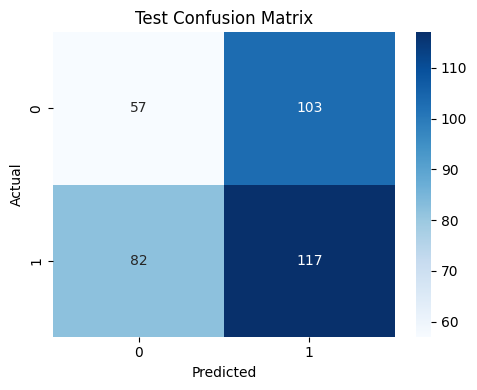

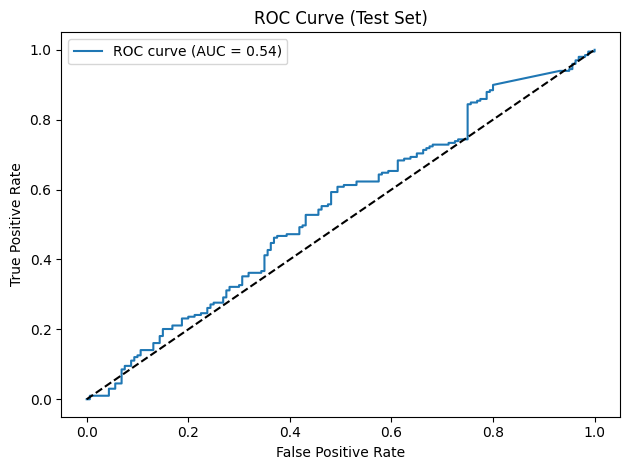

In [16]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_test_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
test_indices = df.iloc[-len(X_test):].index
svm_test_signals = np.where(y_test_pred == 1, 'up', 'down')

In [18]:
features = ['Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Daily Return',
       'Return_lag_1', 'Return_lag_2', 'MA_7', 'MA_30', 'STD_7', 'STD_30',
       'Volume_lag_1', 'Volume_avg_7', 'Volume_change', '30D RV', 'MA_ratio',
       'HL_ratio', 'CO_ratio', 'ADX', 'MACD', 'MACD_Signal',
       'RSI_14', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_%B']

X = df[features]
y = df['Target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

In [19]:
param_grid = {
    'alpha_1': [1e-6, 1e-4, 1e-2, 1e-1],
    'lambda_1': [1e-6, 1e-4, 1e-2, 1e-1],
}

rmse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
grid_search = GridSearchCV(
    BayesianRidge(),
    param_grid,
    scoring=rmse_scorer,
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_
print("Best Estimator:")
print(grid_search.best_params_)

Best Estimator:
{'alpha_1': 1e-06, 'lambda_1': 0.1}


In [21]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n=== Train Metrics ===")
print(f"MAE:  {mean_absolute_error(y_train, y_train_pred):.6f}")
print(f"MSE:  {mean_squared_error(y_train, y_train_pred):.6f}")
print(f"RMSE: {rmse_train:.6f}")
print(f"R²:   {r2_score(y_train, y_train_pred):.6f}")

print("\n=== Test Metrics ===")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred):.6f}")
print(f"MSE:  {mean_squared_error(y_test, y_test_pred):.6f}")
print(f"RMSE: {rmse_test:.6f}")
print(f"R²:   {r2_score(y_test, y_test_pred):.6f}")


=== Train Metrics ===
MAE:  0.012015
MSE:  0.000272
RMSE: 0.016507
R²:   0.013297

=== Test Metrics ===
MAE:  0.008125
MSE:  0.000138
RMSE: 0.011760
R²:   -0.033313


In [22]:
y_pred_mean, y_pred_std = model.predict(X_test, return_std=True)
lower_bound = y_pred_mean - 1.96 * y_pred_std
upper_bound = y_pred_mean + 1.96 * y_pred_std
coverage = np.mean((y_test >= lower_bound) & (y_test <= upper_bound))
print("Interval Coverage Probability (95% CI):", coverage)

Interval Coverage Probability (95% CI): 0.9805013927576601


In [23]:
train_direction_acc = (np.sign(y_train_pred) == np.sign(y_train)).mean()
test_direction_acc = (np.sign(y_test_pred) == np.sign(y_test)).mean()

print("Direction Accuracy (Train):", train_direction_acc)
print("Direction Accuracy (Test):", test_direction_acc)

Direction Accuracy (Train): 0.5334261838440112
Direction Accuracy (Test): 0.5097493036211699


In [26]:
today_close_prices = df.loc[test_indices, "Close"].values
bayesian_predicted_prices = today_close_prices * (1 + y_test_pred)
target_returns = df.loc[test_indices, "Target"].values
actual_target_prices = today_close_prices * (1 + target_returns)

summary_test_df = pd.DataFrame({
    "date": df.loc[test_indices, "Date"].values,
    "close_price": today_close_prices,
    "target_price": actual_target_prices,
    "bayesian_predicted_price": bayesian_predicted_prices,
    "svc_prediction_direction": svm_test_signals
})

In [27]:
summary_test_df.head()


,date,close_price,target_price,bayesian_predicted_price,svc_prediction_direction
0,2016-06-10,96.258,94.796,96.210072,up
1,2016-06-13,94.796,94.914,94.794635,up
2,2016-06-14,94.914,94.602,94.959302,down
3,2016-06-15,94.602,95.000,94.689254,down
4,2016-06-16,95.000,92.839,94.989377,down


In [29]:
# Step 1: Prepare all required arrays
entry_prices = summary_test_df["close_price"].values[:-1]                # Pₜ
predicted_exit_prices = summary_test_df["bayesian_predicted_price"].values[:-1]  # model(Pₜ₊₁)
true_exit_prices = summary_test_df["target_price"].values[1:]           # actual Pₜ₊₁
svm_directions = summary_test_df["svc_prediction_direction"].values[:-1]

# Step 2: Signal: Buy if SVM says "up" and Bayesian says price↑
signals = ((svm_directions == "up") & (predicted_exit_prices > entry_prices)).astype(int)

# Step 3: Stop-loss and Take-profit levels
stop_loss_pct = 0.03
take_profit_pct = 0.05
stop_loss_price = entry_prices * (1 - stop_loss_pct)
take_profit_price = entry_prices * (1 + take_profit_pct)

# Step 4: Exit price logic (SL or TP applied to real next-day close)
final_exit_prices = np.where(
    true_exit_prices < stop_loss_price,
    stop_loss_price,
    np.where(true_exit_prices > take_profit_price, take_profit_price, true_exit_prices)
)

# Step 5: Trade Returns (only where signals == 1)
returns = np.where(signals == 1, (final_exit_prices - entry_prices) / entry_prices, 0.0)

# Step 6: Backtest P&L assuming full capital used per trade, 1 position at a time
initial_cash = 100000
cash = initial_cash
portfolio = []

for r in returns:
    cash = cash * (1 + r)
    portfolio.append(cash)

# Step 7: Metrics
pnl = cash - initial_cash
portfolio_array = np.array([initial_cash] + portfolio)
returns_pct = np.diff(portfolio_array) / portfolio_array[:-1]
sharpe = (np.mean(returns_pct) / np.std(returns_pct)) * np.sqrt(252) if np.std(returns_pct) > 0 else 0
drawdown = np.array(portfolio) / np.maximum.accumulate(portfolio) - 1
max_drawdown = drawdown.min()

# Step 8: Report
print("=== Hybrid Strategy Backtest Results ===")
print(f"Total Trades: {signals.sum()}")
print(f"P&L: ₹{pnl:.2f}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_drawdown * 100:.2f}%")
print(f"Total Return: {((cash / initial_cash) - 1) * 100:.2f}%")

=== Hybrid Strategy Backtest Results ===
Total Trades: 68
P&L: ₹58845.77
Sharpe Ratio: 3.02
Max Drawdown: -3.91%
Total Return: 58.85%
